# Model Comparison & Correlation Analysis

**Obiettivo:** Confronto completo di tutti i modelli addestrati e analisi di correlazione tra le loro predizioni

**Dataset:** processed_v4_hybrid (unified dataset per tutti i modelli)

**Modelli analizzati:**
1. **XGBoost_v2** (binary: Non-TP vs TP)
2. **Random Forest** (binary: Non-TP vs TP)
3. **Decision Tree** (binary: Non-TP vs TP)
4. **MLP Baseline** (binary con class weights)

**Analisi:**
1. Confronto metriche (Accuracy, F1, ROC AUC)
2. Visualizzazione comparativa
3. Matrice di correlazione tra predizioni
4. Agreement analysis (dove i modelli concordano/discordano)
5. Feature importance comparison

**Hardware:** Supporto GPU NVIDIA (CUDA), Apple Silicon (MPS), CPU

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Setup device (CUDA > MPS > CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"🎮 Device: {device} ({torch.cuda.get_device_name(0)})")
    print(f"   CUDA version: {torch.version.cuda}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"🍎 Device: {device} (Metal Performance Shaders)")
else:
    device = torch.device('cpu')
    print(f"💻 Device: {device}")

print(f"🐍 PyTorch version: {torch.__version__}")
print("✅ Librerie importate con successo!")

🎮 Device: cuda (NVIDIA GeForce RTX 3060 Ti)
   CUDA version: 12.1
🐍 PyTorch version: 2.5.1+cu121
✅ Librerie importate con successo!


## 2. Caricamento Metriche Salvate

In [3]:
# Carica metriche JSON
models_dir = Path('../models')

metrics = {}

# Carica tutte le metriche disponibili (tutti addestrati su v4_hybrid)
model_paths = {
    'XGBoost': 'xgboost_v2',
    'Random Forest': 'random_forest_v2',
    'Decision Tree': 'decision_tree',
    'MLP': 'mlp_baseline'
}

print("Caricamento metriche...\n")
for model_name, model_path in model_paths.items():
    metrics_file = models_dir / model_path / 'metrics.json'
    if metrics_file.exists():
        with open(metrics_file, 'r') as f:
            metrics[model_name] = json.load(f)
        print(f"✅ {model_name:30s} - {metrics[model_name]['timestamp'][:10]}")
    else:
        print(f"⚠️  {model_name:30s} - File non trovato")

print(f"\n{len(metrics)} modelli caricati con successo!")

Caricamento metriche...

✅ XGBoost                        - 2025-11-06
✅ Random Forest                  - 2025-11-01
✅ Decision Tree                  - 2025-11-06
✅ MLP                            - 2025-11-06

4 modelli caricati con successo!


## 3. Confronto Metriche Generali

In [4]:
# Helper function per estrarre metriche (gestisce differenze tra multi-class e binary)
def get_metric(model_metrics, metric_name):
    """Estrae una metrica, gestendo nomi diversi tra modelli"""
    # Mapping dei nomi delle metriche
    metric_mappings = {
        'accuracy': ['test_accuracy', 'accuracy'],
        'f1': ['test_macro_f1', 'test_f1_score', 'f1_score'],
        'precision': ['test_precision', 'precision'],
        'recall': ['test_recall', 'recall'],
        'roc_auc': ['roc_auc_micro', 'test_roc_auc', 'roc_auc']
    }
    
    # Prova le diverse chiavi possibili
    test_metrics = model_metrics.get('test_metrics', {})
    
    for possible_key in metric_mappings.get(metric_name, [metric_name]):
        if possible_key in model_metrics:
            return model_metrics[possible_key]
        if possible_key in test_metrics:
            return test_metrics[possible_key]
    
    return None

# Crea DataFrame per confronto
comparison_data = {
    'Model': [],
    'Type': [],
    'Dataset': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC AUC': [],
    'N Features': [],
    'Train Samples': [],
    'Test Samples': []
}

for model_name, model_metrics in metrics.items():
    comparison_data['Model'].append(model_name)
    
    # Tutti i modelli sono Binary e usano v4_hybrid
    comparison_data['Type'].append('Binary')
    comparison_data['Dataset'].append('v4_hybrid')
    
    # Estrai metriche
    comparison_data['Accuracy'].append(get_metric(model_metrics, 'accuracy'))
    comparison_data['Precision'].append(get_metric(model_metrics, 'precision'))
    comparison_data['Recall'].append(get_metric(model_metrics, 'recall'))
    comparison_data['F1-Score'].append(get_metric(model_metrics, 'f1'))
    comparison_data['ROC AUC'].append(get_metric(model_metrics, 'roc_auc'))
    
    # Dati dataset
    data_info = model_metrics.get('data', {})
    comparison_data['N Features'].append(data_info.get('n_features', model_metrics.get('n_features', 'N/A')))
    comparison_data['Train Samples'].append(data_info.get('n_train_samples', model_metrics.get('n_train_samples', 'N/A')))
    comparison_data['Test Samples'].append(data_info.get('n_test_samples', model_metrics.get('n_test_samples', 'N/A')))

comparison_df = pd.DataFrame(comparison_data)

print("=" * 120)
print("CONFRONTO METRICHE - TUTTI I MODELLI (Dataset: v4_hybrid)")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)

# Identifica il migliore per ogni metrica (solo valori numerici)
print("\n🏆 MIGLIOR MODELLO PER METRICA:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']:
    valid_data = comparison_df[comparison_df[metric].notna()]
    if len(valid_data) > 0:
        best_idx = valid_data[metric].idxmax()
        best_model = comparison_df.loc[best_idx, 'Model']
        best_value = comparison_df.loc[best_idx, metric]
        print(f"  {metric:12s}: {best_model:30s} ({best_value:.4f})")
    else:
        print(f"  {metric:12s}: N/A")

CONFRONTO METRICHE - TUTTI I MODELLI (Dataset: v4_hybrid)
        Model   Type   Dataset  Accuracy  Precision   Recall  F1-Score  ROC AUC  N Features  Train Samples  Test Samples
      XGBoost Binary v4_hybrid  0.878632   0.816066 0.752974  0.783252 0.930732          43         243878        149537
Random Forest Binary v4_hybrid  0.881695   0.848795 0.722480  0.780560 0.924035          43         304848        149537
Decision Tree Binary v4_hybrid  0.871102   0.794979 0.751114  0.772424 0.922394          43         304848        149537
          MLP Binary v4_hybrid  0.867491   0.788109 0.745419  0.766170 0.919976          43         243878        149537

🏆 MIGLIOR MODELLO PER METRICA:
        Model   Type   Dataset  Accuracy  Precision   Recall  F1-Score  ROC AUC  N Features  Train Samples  Test Samples
      XGBoost Binary v4_hybrid  0.878632   0.816066 0.752974  0.783252 0.930732          43         243878        149537
Random Forest Binary v4_hybrid  0.881695   0.848795 0.722480  0

## 4. Visualizzazione Comparativa Metriche

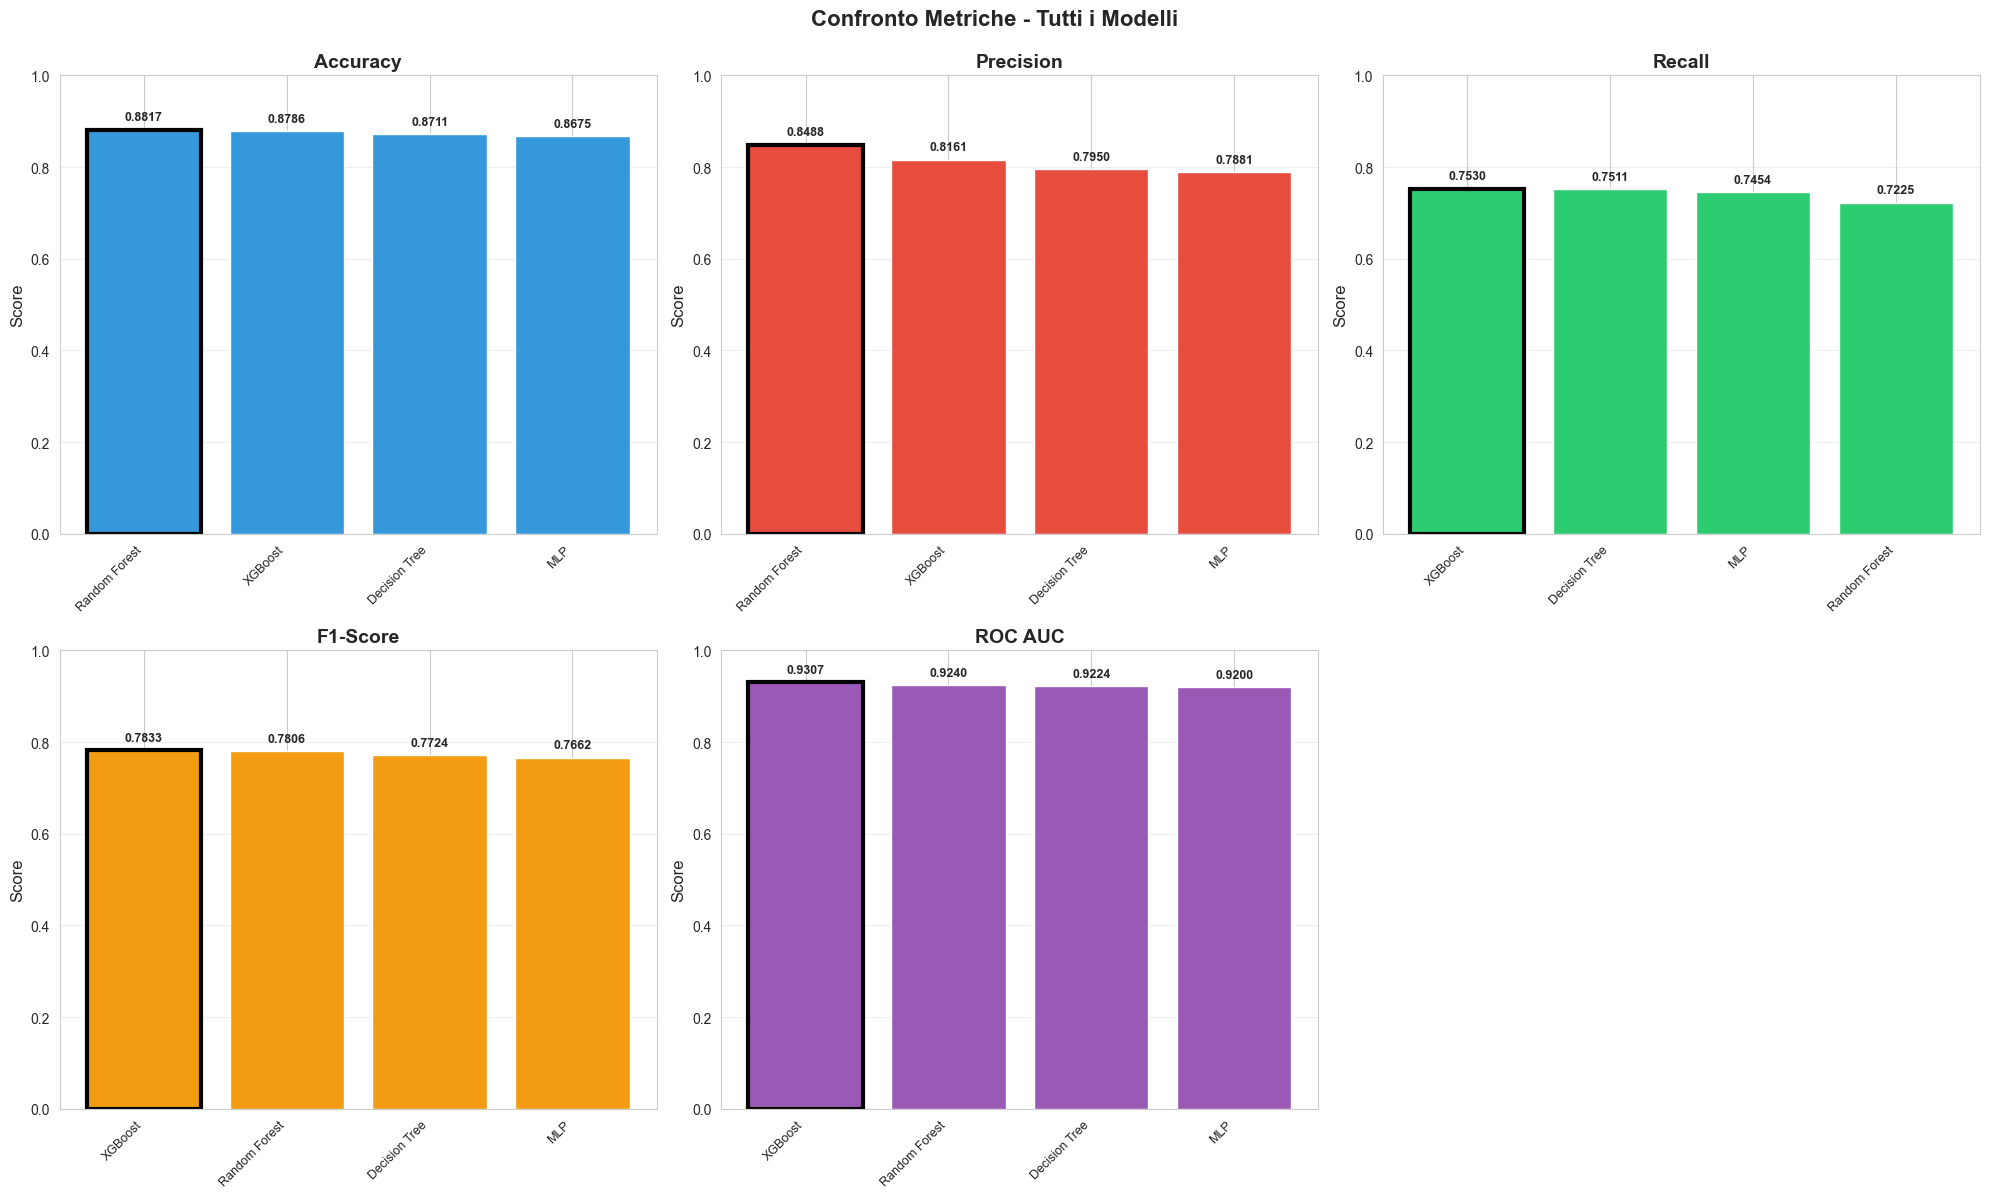

✅ Grafico salvato: ../models/metrics_comparison_all.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # Filtra valori validi
    valid_data = comparison_df[comparison_df[metric].notna()].copy()
    
    if len(valid_data) > 0:
        # Ordina per valore
        valid_data = valid_data.sort_values(metric, ascending=False)
        
        bars = ax.bar(range(len(valid_data)), valid_data[metric], color=colors[i])
        
        # Evidenzia il migliore
        best_idx = 0  # già ordinato in modo decrescente
        bars[best_idx].set_edgecolor('black')
        bars[best_idx].set_linewidth(3)
        
        ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Score', fontsize=12)
        ax.set_ylim(0, 1)
        ax.set_xticks(range(len(valid_data)))
        ax.set_xticklabels(valid_data['Model'], rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Aggiungi valori sopra le barre
        for j, v in enumerate(valid_data[metric]):
            ax.text(j, v + 0.02, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{metric}', fontsize=14, fontweight='bold')

# Rimuovi l'ultimo subplot se non usato
axes[-1].axis('off')

plt.suptitle('Confronto Metriche - Tutti i Modelli', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../models/metrics_comparison_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato: ../models/metrics_comparison_all.png")

## 6. ROC AUC Comparison

Confronto ROC AUC tra tutti i modelli (multi-class e binary).

## 5. Confronto Dettagliato Modelli Binari

I modelli binari sono più direttamente confrontabili tra loro.

CONFRONTO MODELLI BINARI (Non-TP vs TP)
        Model   Dataset  Accuracy  Precision   Recall  F1-Score  ROC AUC
      XGBoost v4_hybrid  0.878632   0.816066 0.752974  0.783252 0.930732
Random Forest v4_hybrid  0.881695   0.848795 0.722480  0.780560 0.924035
Decision Tree v4_hybrid  0.871102   0.794979 0.751114  0.772424 0.922394
          MLP v4_hybrid  0.867491   0.788109 0.745419  0.766170 0.919976


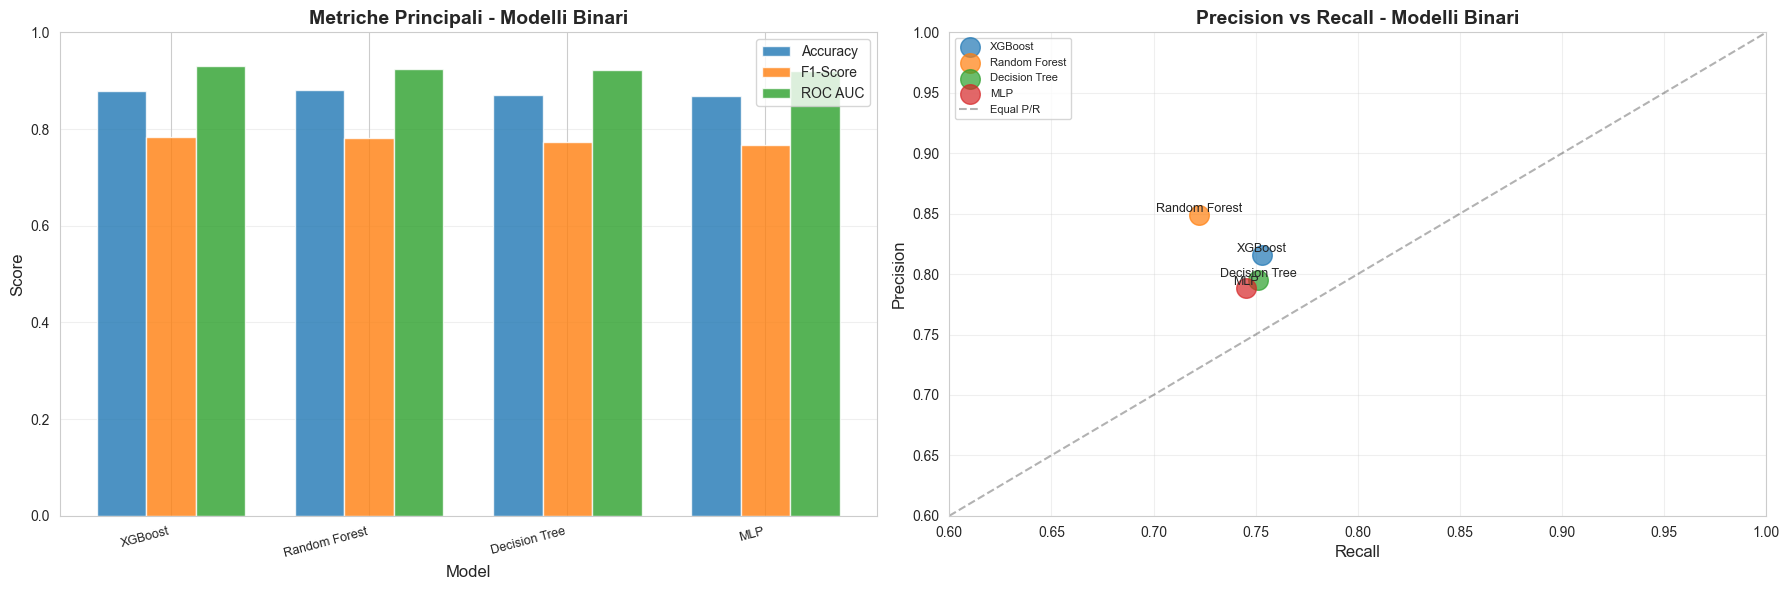


✅ Grafico salvato: ../models/binary_models_comparison.png


In [6]:
# Filtra solo modelli binari
binary_models = comparison_df[comparison_df['Type'] == 'Binary'].copy()

print("=" * 100)
print("CONFRONTO MODELLI BINARI (Non-TP vs TP)")
print("=" * 100)
print(binary_models[['Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']].to_string(index=False))
print("=" * 100)

# Visualizza confronto binari
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Metriche principali
metrics_bin = ['Accuracy', 'F1-Score', 'ROC AUC']
x = np.arange(len(binary_models))
width = 0.25

for i, metric in enumerate(metrics_bin):
    ax = axes[0]
    offset = width * (i - 1)
    bars = ax.bar(x + offset, binary_models[metric], width, label=metric, alpha=0.8)
    
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metriche Principali - Modelli Binari', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(binary_models['Model'], rotation=15, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1)

# Precision vs Recall
ax = axes[1]
for idx, row in binary_models.iterrows():
    ax.scatter(row['Recall'], row['Precision'], s=200, alpha=0.7, label=row['Model'])
    ax.annotate(row['Model'], (row['Recall'], row['Precision']), 
                fontsize=9, ha='center', va='bottom')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision vs Recall - Modelli Binari', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xlim(0.6, 1.0)
ax.set_ylim(0.6, 1.0)
# Diagonale (F1 costante)
ax.plot([0.6, 1.0], [0.6, 1.0], 'k--', alpha=0.3, label='Equal P/R')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../models/binary_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato: ../models/binary_models_comparison.png")

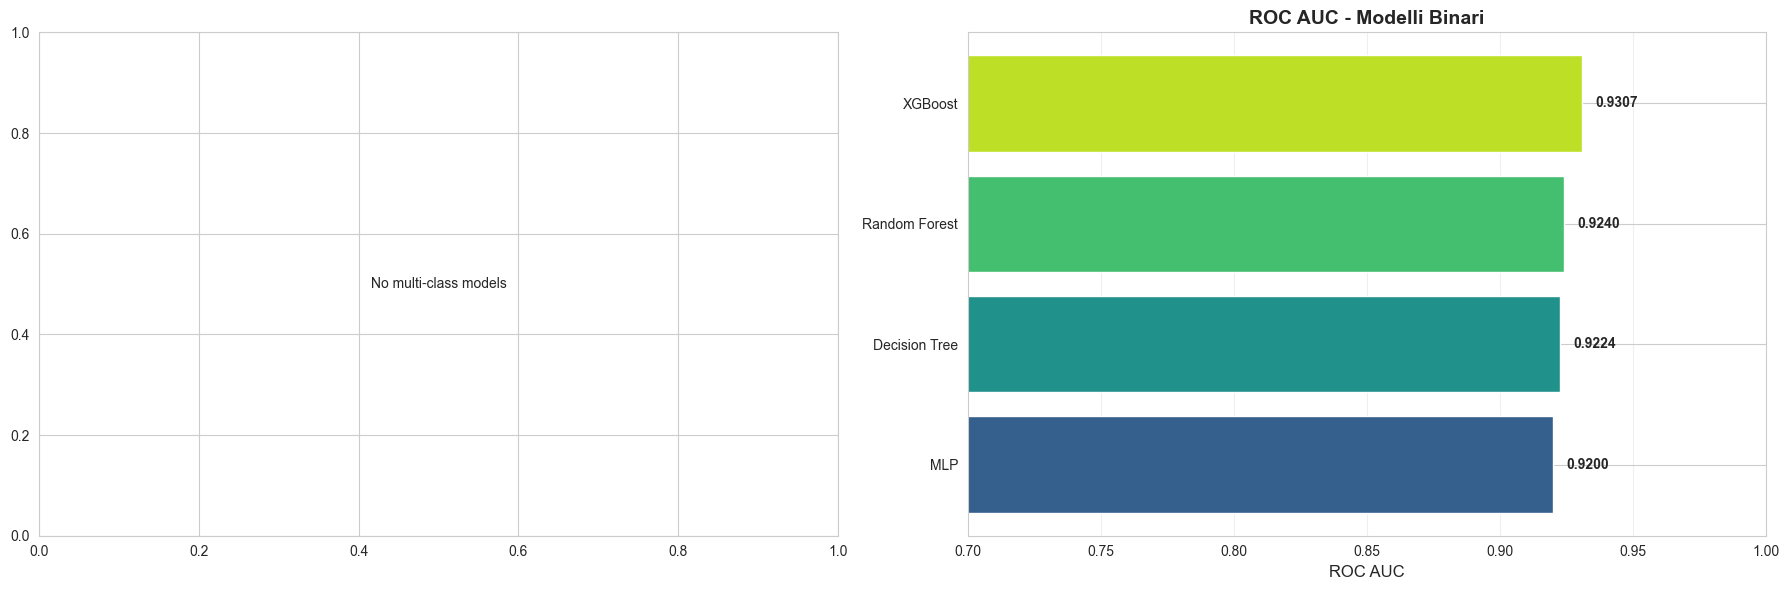


✅ Grafico salvato: ../models/roc_auc_all_models_comparison.png


In [7]:
# Confronto ROC AUC per tutti i modelli
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Per multi-class: confronta ROC AUC per classe
multi_models = comparison_df[comparison_df['Type'] == 'Multi-class']
if len(multi_models) > 0:
    ax = axes[0]
    
    classes = ['BenignPositive', 'FalsePositive', 'TruePositive']
    x = np.arange(len(classes))
    width = 0.35
    
    for i, model_name in enumerate(multi_models['Model']):
        model_metrics = metrics[model_name]
        roc_per_class = model_metrics.get('roc_auc_per_class', {})
        
        if roc_per_class:
            values = [roc_per_class.get(cls, 0) for cls in classes]
            offset = width * (i - 0.5)
            ax.bar(x + offset, values, width, label=model_name, alpha=0.8)
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('ROC AUC', fontsize=12)
    ax.set_title('ROC AUC per Classe - Modelli Multi-Class', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0.6, 0.85)
else:
    axes[0].text(0.5, 0.5, 'No multi-class models', ha='center', va='center', transform=axes[0].transAxes)

# Per binary: ROC AUC complessivo
ax = axes[1]
binary_models_sorted = binary_models.sort_values('ROC AUC', ascending=True)
colors_bin = plt.cm.viridis(np.linspace(0.3, 0.9, len(binary_models_sorted)))

bars = ax.barh(binary_models_sorted['Model'], binary_models_sorted['ROC AUC'], color=colors_bin)
ax.set_xlabel('ROC AUC', fontsize=12)
ax.set_title('ROC AUC - Modelli Binari', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.7, 1.0)

# Aggiungi valori
for i, v in enumerate(binary_models_sorted['ROC AUC']):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/roc_auc_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato: ../models/roc_auc_all_models_comparison.png")

## 7. Confusion Matrices - Modelli Binari

Confronto delle confusion matrices per tutti i modelli binari.

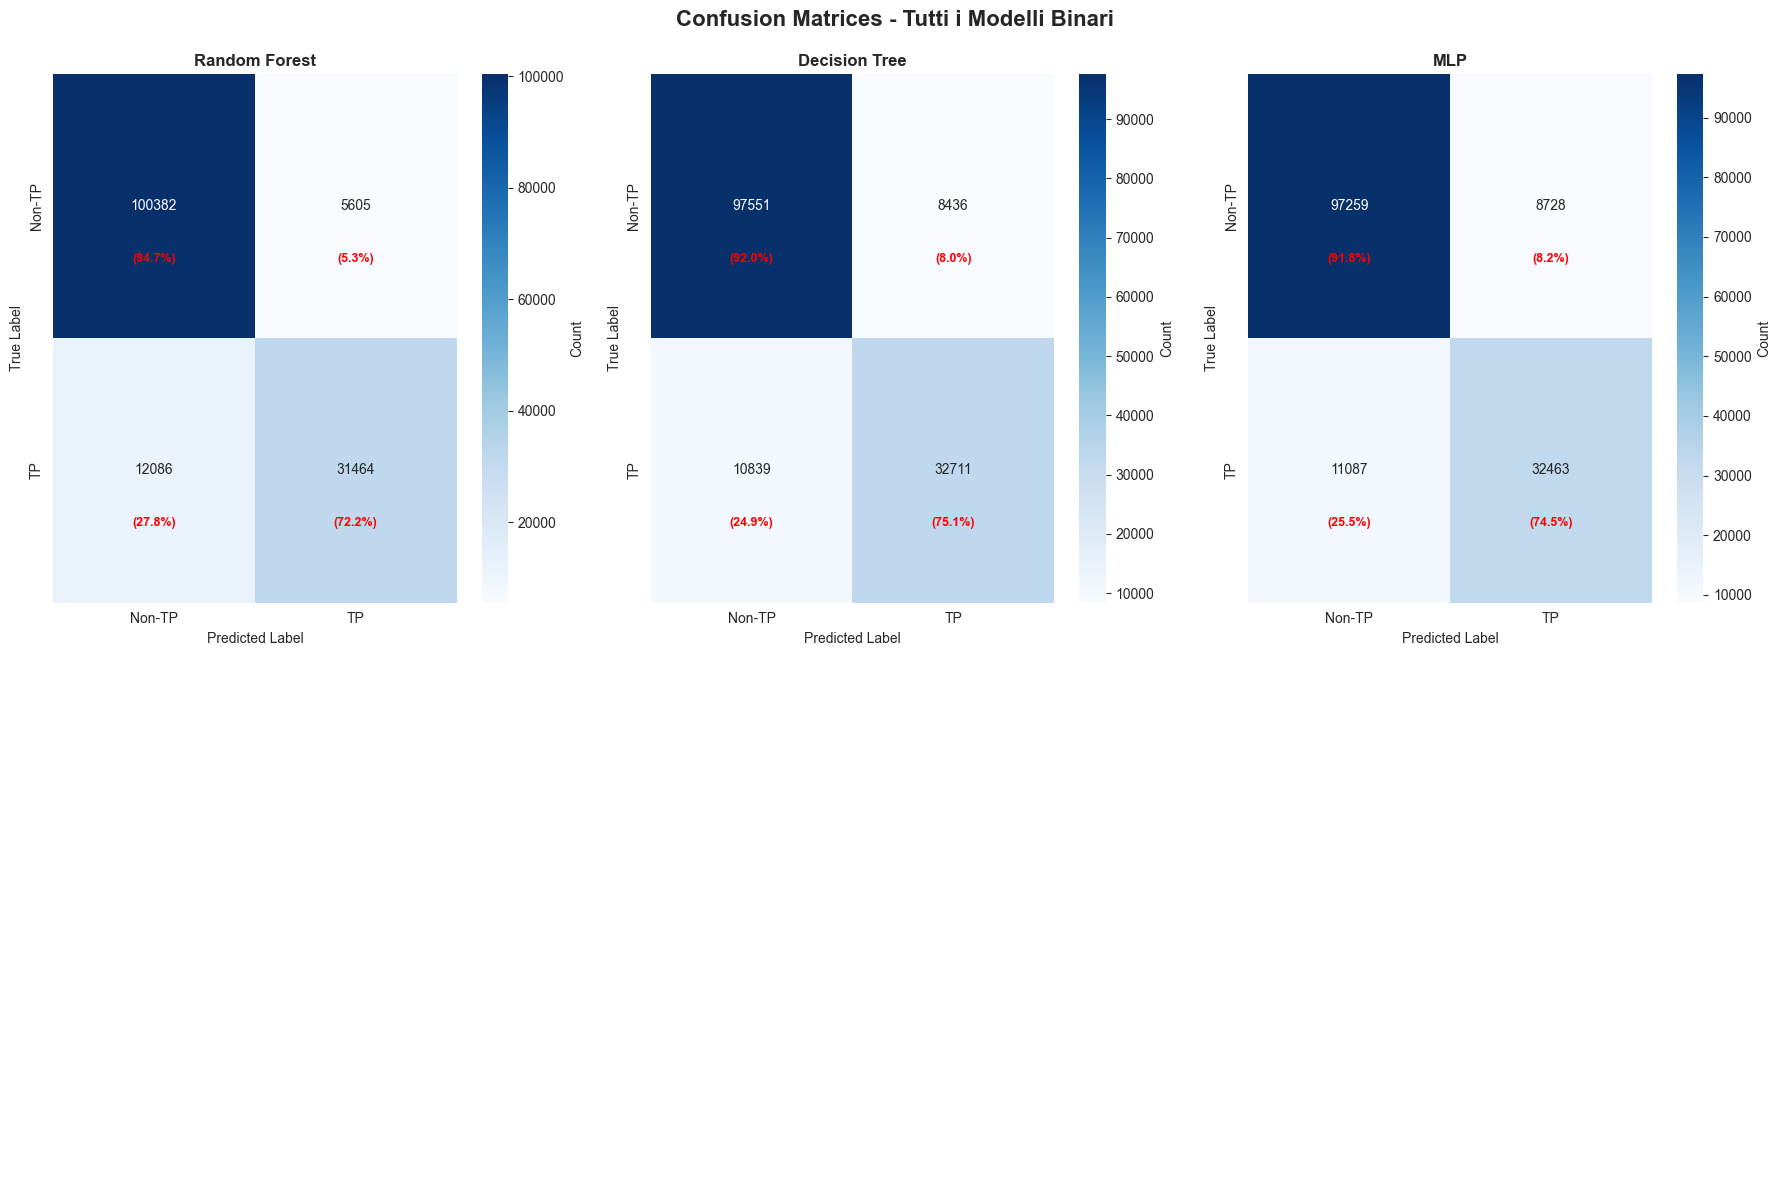

✅ Grafico salvato: ../models/confusion_matrices_all_binary.png

STATISTICHE CONFUSION MATRICES

Random Forest:
  TN: 100,382  |  FP:  5,605
  FN: 12,086  |  TP: 31,464
  Accuracy: 0.8817
  TPR (Recall): 0.7225
  TNR (Specificity): 0.9471

Decision Tree:
  TN: 97,551  |  FP:  8,436
  FN: 10,839  |  TP: 32,711
  Accuracy: 0.8711
  TPR (Recall): 0.7511
  TNR (Specificity): 0.9204

MLP:
  TN: 97,259  |  FP:  8,728
  FN: 11,087  |  TP: 32,463
  Accuracy: 0.8675
  TPR (Recall): 0.7454
  TNR (Specificity): 0.9177


In [8]:
# Estrai confusion matrices da metriche salvate
binary_cms = {}

for model_name in binary_models['Model']:
    cm_data = metrics[model_name].get('confusion_matrix', {})
    if cm_data:
        cm = np.array([
            [cm_data.get('true_negatives', 0), cm_data.get('false_positives', 0)],
            [cm_data.get('false_negatives', 0), cm_data.get('true_positives', 0)]
        ])
        binary_cms[model_name] = cm

# Visualizza tutte le confusion matrices
n_models = len(binary_cms)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (model_name, cm) in enumerate(binary_cms.items()):
    ax = axes[i]
    
    # Normalizza per percentuali
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-TP', 'TP'], yticklabels=['Non-TP', 'TP'],
                cbar_kws={'label': 'Count'})
    
    # Aggiungi percentuali
    for j in range(2):
        for k in range(2):
            text = ax.text(k + 0.5, j + 0.7, f'({cm_norm[j, k]:.1%})',
                          ha="center", va="center", color="red", fontsize=9, fontweight='bold')
    
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Rimuovi subplot extra
for i in range(n_models, len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrices - Tutti i Modelli Binari', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../models/confusion_matrices_all_binary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato: ../models/confusion_matrices_all_binary.png")

# Stampa statistiche
print("\n" + "=" * 80)
print("STATISTICHE CONFUSION MATRICES")
print("=" * 80)
for model_name, cm in binary_cms.items():
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    print(f"\n{model_name}:")
    print(f"  TN: {tn:6,}  |  FP: {fp:6,}")
    print(f"  FN: {fn:6,}  |  TP: {tp:6,}")
    print(f"  Accuracy: {(tn + tp) / (tn + fp + fn + tp):.4f}")
    print(f"  TPR (Recall): {tp / (tp + fn):.4f}")
    print(f"  TNR (Specificity): {tn / (tn + fp):.4f}")
print("=" * 80)

## 8. Feature Importance Comparison

Confronto delle top features per tutti i modelli che hanno feature importance salvata.

In [9]:
# Carica feature importance per tutti i modelli disponibili
feature_importances = {}

for model_name, model_path in model_paths.items():
    feat_imp_path = models_dir / model_path / 'feature_importance.csv'
    if feat_imp_path.exists():
        feature_importances[model_name] = pd.read_csv(feat_imp_path)
        print(f"✅ {model_name:30s} - {len(feature_importances[model_name])} features")
    else:
        print(f"⚠️  {model_name:30s} - Feature importance non trovata")

print(f"\n{len(feature_importances)} modelli con feature importance caricati!")

# Mostra top 10 features per ogni modello
for model_name, feat_df in feature_importances.items():
    print(f"\n{'='*80}")
    print(f"Top 10 Features - {model_name}")
    print(f"{'='*80}")
    print(feat_df.head(10).to_string(index=False))

✅ XGBoost                        - 43 features
✅ Random Forest                  - 43 features
✅ Decision Tree                  - 43 features
⚠️  MLP                            - Feature importance non trovata

3 modelli con feature importance caricati!

Top 10 Features - XGBoost
                    Feature  Importance
     ResourceType_freq_mean    0.330654
   ActionGranular_freq_mean    0.246145
    ActionGrouped_freq_mean    0.230611
            Roles_freq_mean    0.053303
           SmoothedRisk_avg    0.032188
                  T1078_sum    0.019661
     ThreatFamily_freq_mean    0.011508
            GeoLoc_freq_avg    0.009900
      LastVerdict_freq_mean    0.009739
AntispamDirection_freq_mean    0.004800

Top 10 Features - Random Forest
                    Feature  Importance
           SmoothedRisk_avg    0.276618
            Roles_freq_mean    0.097903
   ActionGranular_freq_mean    0.080542
     ResourceType_freq_mean    0.074982
     ThreatFamily_freq_mean    0.071348
    Act

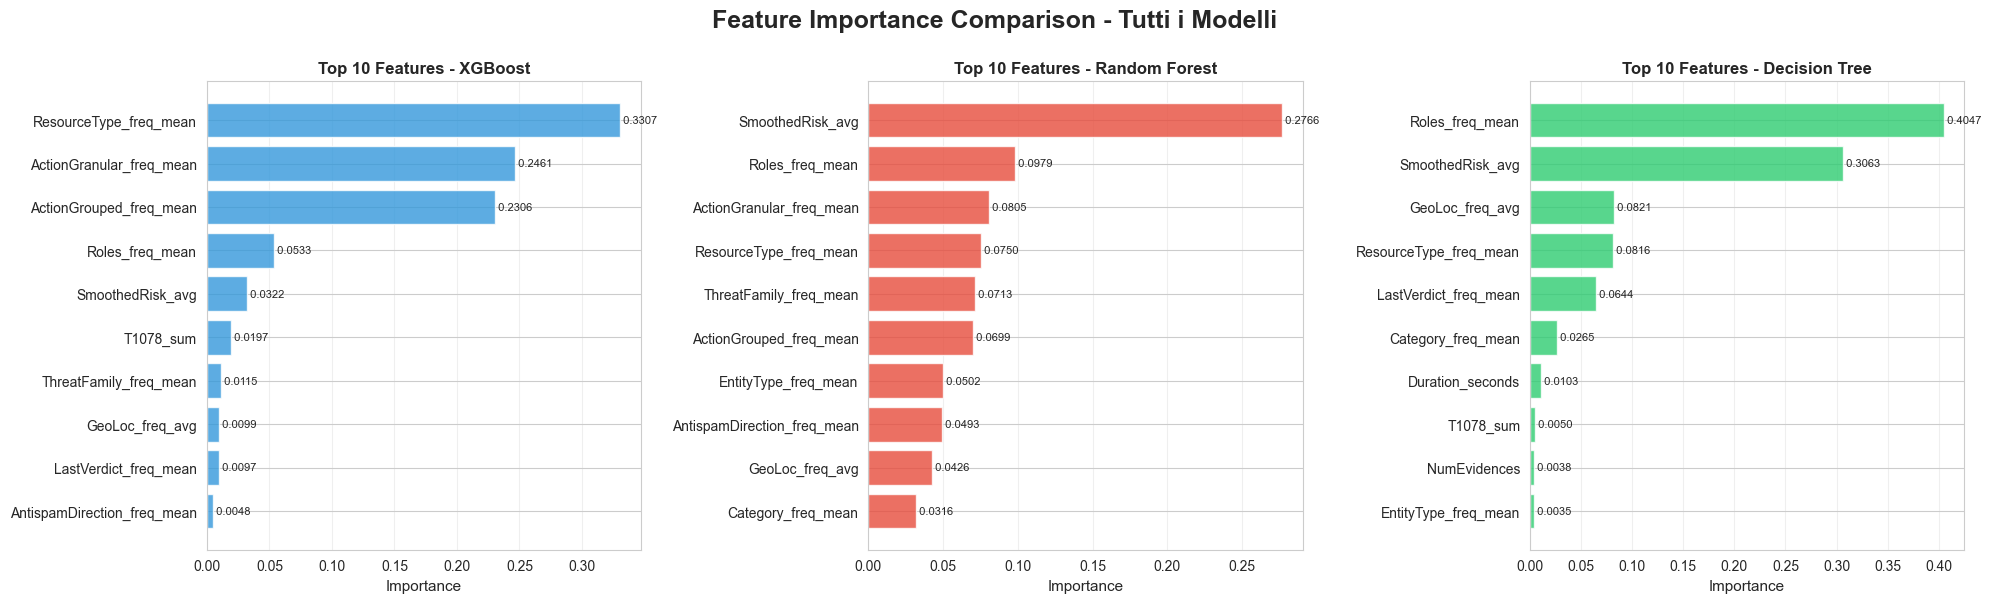


✅ Grafico salvato: ../models/feature_importance_all_models.png


In [10]:
# Visualizza top 10 features per tutti i modelli
n_models = len(feature_importances)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (model_name, feat_df) in enumerate(feature_importances.items()):
    ax = axes[i]
    
    top_features = feat_df.head(10).sort_values('Importance', ascending=True)
    
    ax.barh(top_features['Feature'], top_features['Importance'], 
            color=colors_palette[i % len(colors_palette)], alpha=0.8)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'Top 10 Features - {model_name}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Aggiungi valori
    for j, (feat, imp) in enumerate(zip(top_features['Feature'], top_features['Importance'])):
        ax.text(imp, j, f' {imp:.4f}', va='center', fontsize=8)

# Rimuovi subplot extra
for i in range(n_models, len(axes)):
    axes[i].axis('off')

plt.suptitle('Feature Importance Comparison - Tutti i Modelli', fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig('../models/feature_importance_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato: ../models/feature_importance_all_models.png")

### 8.1 Features Comuni più Importanti

Identifichiamo le features che appaiono nel top 10 di più modelli.

TOP 15 FEATURES PIÙ COMUNI (presenti in top 10 di più modelli)
                    Feature  Count  Percentage
     ResourceType_freq_mean      3       100.0
            Roles_freq_mean      3       100.0
           SmoothedRisk_avg      3       100.0
            GeoLoc_freq_avg      3       100.0
   ActionGranular_freq_mean      2        66.7
    ActionGrouped_freq_mean      2        66.7
                  T1078_sum      2        66.7
     ThreatFamily_freq_mean      2        66.7
      LastVerdict_freq_mean      2        66.7
AntispamDirection_freq_mean      2        66.7
       EntityType_freq_mean      2        66.7
         Category_freq_mean      2        66.7
           Duration_seconds      1        33.3
               NumEvidences      1        33.3


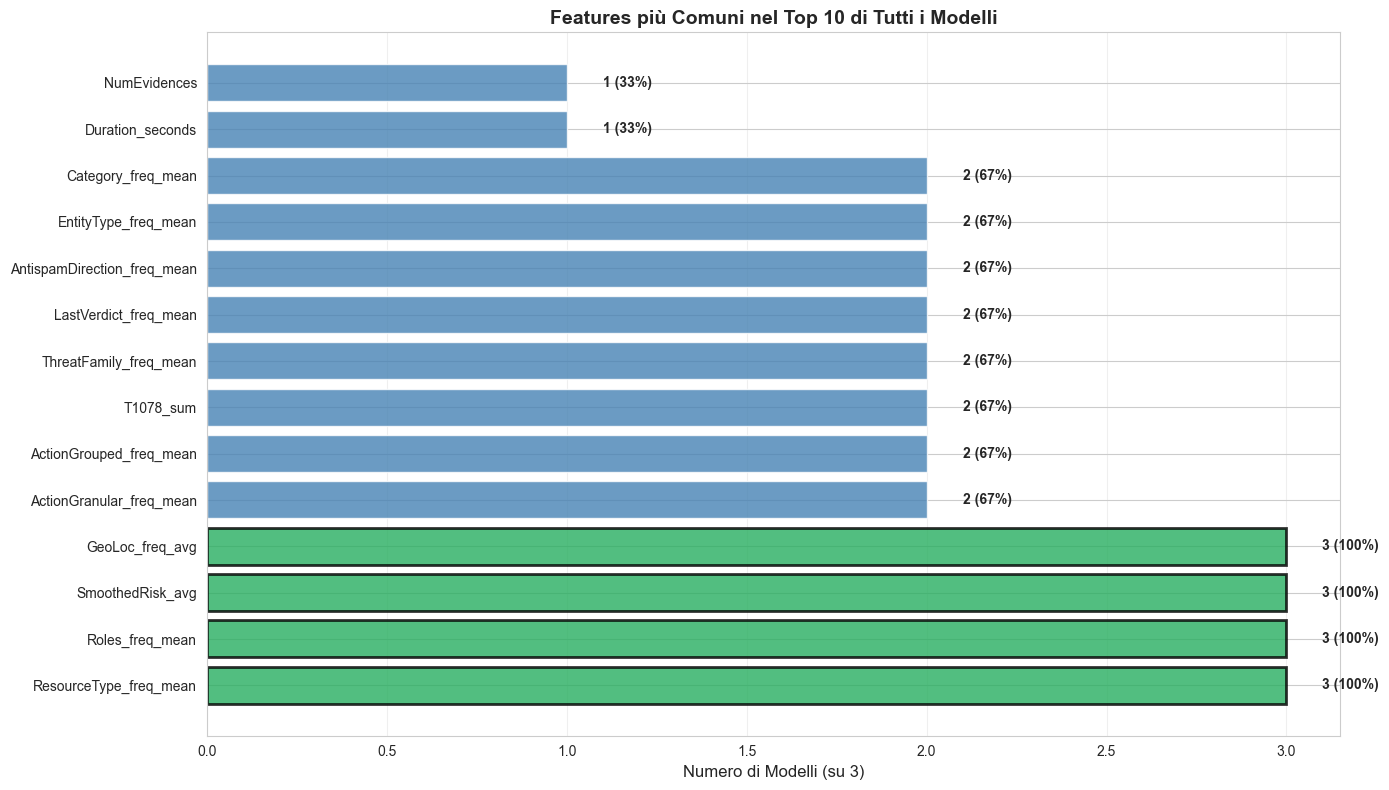


✅ Grafico salvato: ../models/common_top_features.png

💡 Features in verde: presenti nel top 10 di TUTTI i modelli


In [11]:
# Conta quante volte ogni feature appare nel top 10
from collections import Counter

top_features_count = Counter()

for model_name, feat_df in feature_importances.items():
    top_10_features = feat_df.head(10)['Feature'].tolist()
    top_features_count.update(top_10_features)

# Ordina per frequenza
common_features = pd.DataFrame(top_features_count.most_common(15), 
                               columns=['Feature', 'Count'])
common_features['Percentage'] = (common_features['Count'] / len(feature_importances) * 100).round(1)

print("=" * 70)
print("TOP 15 FEATURES PIÙ COMUNI (presenti in top 10 di più modelli)")
print("=" * 70)
print(common_features.to_string(index=False))
print("=" * 70)

# Visualizza
fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(common_features['Feature'], common_features['Count'], color='steelblue', alpha=0.8)

# Colora diversamente le features presenti in tutti i modelli
for i, bar in enumerate(bars):
    if common_features.iloc[i]['Count'] == len(feature_importances):
        bar.set_color('#27ae60')
        bar.set_edgecolor('black')
        bar.set_linewidth(2)

ax.set_xlabel('Numero di Modelli (su {})'.format(len(feature_importances)), fontsize=12)
ax.set_title('Features più Comuni nel Top 10 di Tutti i Modelli', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Aggiungi valori e percentuali
for i, (feat, count, pct) in enumerate(zip(common_features['Feature'], 
                                            common_features['Count'], 
                                            common_features['Percentage'])):
    ax.text(count + 0.1, i, f'{count} ({pct:.0f}%)', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/common_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato: ../models/common_top_features.png")
print("\n💡 Features in verde: presenti nel top 10 di TUTTI i modelli")

## 12. Summary Report

## 9. Model Predictions Correlation Matrix

Analizza la correlazione tra le predizioni dei diversi modelli per capire quanto sono simili/diversi nelle loro decisioni.

In [12]:
# Per creare una correlation matrix, dobbiamo caricare le predizioni dei modelli
# Tutti i modelli condividono lo stesso test set (processed_v4_hybrid)

print("Caricamento test set v4_hybrid...\n")

# Carica test set v4_hybrid (usato da tutti i modelli)
X_test = pd.read_csv('../data/processed_v4_hybrid/X_test.csv')
y_test = pd.read_csv('../data/processed_v4_hybrid/y_test.csv')['BinaryIncidentGrade']

print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")
print(f"Target distribution:\n{y_test.value_counts()}\n")

# Dictionary per salvare le predizioni
predictions = {}

# Definizione MLP architecture (stessa usata nel training)
class MLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# Device già configurato nella cella Setup
print(f"🖥️  Using device: {device}\n")

# 1. XGBoost_v2
try:
    xgb_v2 = xgb.XGBClassifier()
    xgb_v2.load_model('../models/xgboost_v2/model.json')
    predictions['XGBoost_v2'] = xgb_v2.predict(X_test)
    print("✅ XGBoost_v2: predizioni caricate")
except Exception as e:
    print(f"⚠️  XGBoost_v2: {e}")

# 2. Random Forest
try:
    import pickle
    with open('../models/random_forest_v2/model.pkl', 'rb') as f:
        rf_model = pickle.load(f)
    predictions['Random_Forest'] = rf_model.predict(X_test)
    print("✅ Random Forest: predizioni caricate")
except Exception as e:
    print(f"⚠️  Random Forest: {e}")

# 3. Decision Tree
try:
    import pickle
    with open('../models/decision_tree/model.pkl', 'rb') as f:
        dt_model = pickle.load(f)
    predictions['Decision_Tree'] = dt_model.predict(X_test)
    print("✅ Decision Tree: predizioni caricate")
except Exception as e:
    print(f"⚠️  Decision Tree: {e}")

# 4. MLP Baseline
try:
    # Carica modello
    mlp_baseline = MLP(X_test.shape[1]).to(device)
    mlp_baseline.load_state_dict(torch.load('../models/mlp_baseline/model_weights.pth', map_location=device))
    mlp_baseline.eval()
    
    # Standardizza dati (CRITICO per MLP!)
    # Ricrea lo scaler dal training (usa solo train_final per fit)
    from sklearn.model_selection import train_test_split
    X_train_full = pd.read_csv('../data/processed_v4_hybrid/X_train.csv')
    y_train_full = pd.read_csv('../data/processed_v4_hybrid/y_train.csv')['BinaryIncidentGrade']
    X_train_final, _, _, _ = train_test_split(X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)
    
    mlp_scaler = StandardScaler()
    mlp_scaler.fit(X_train_final)
    X_test_scaled = mlp_scaler.transform(X_test)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    
    # Batch processing ottimizzato per GPU
    batch_size = 4096 if device.type == 'cuda' else 2048
    test_dataset = TensorDataset(X_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    predictions_list = []
    with torch.no_grad():
        for (batch_X,) in test_loader:
            batch_X = batch_X.to(device)
            outputs = mlp_baseline(batch_X)
            batch_preds = (torch.sigmoid(outputs).squeeze() > 0.5).cpu().numpy().astype(int)
            predictions_list.extend(batch_preds)
    
    predictions['MLP_Baseline'] = np.array(predictions_list)
    print("✅ MLP Baseline: predizioni caricate")
except Exception as e:
    print(f"⚠️  MLP Baseline: {e}")

print(f"\n{len(predictions)} modelli caricati per correlation analysis")

Caricamento test set v4_hybrid...

Test set: 149,537 samples, 43 features
Target distribution:
BinaryIncidentGrade
0    105987
1     43550
Name: count, dtype: int64

🖥️  Using device: cuda

✅ XGBoost_v2: predizioni caricate


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


✅ Random Forest: predizioni caricate
✅ Decision Tree: predizioni caricate
✅ MLP Baseline: predizioni caricate

4 modelli caricati per correlation analysis


PREDICTION SAMPLES
    XGBoost_v2  Random_Forest  Decision_Tree  MLP_Baseline  True_Label
0            1              1              1             1           1
1            1              1              1             1           1
2            0              0              0             0           0
3            1              1              1             1           1
4            0              0              0             0           1
5            0              0              0             0           0
6            0              0              0             0           0
7            0              0              0             0           0
8            1              1              1             1           1
9            1              1              1             1           1
10           0              0              0             0           0
11           0              0              0             0           0
12           0              0              0             0

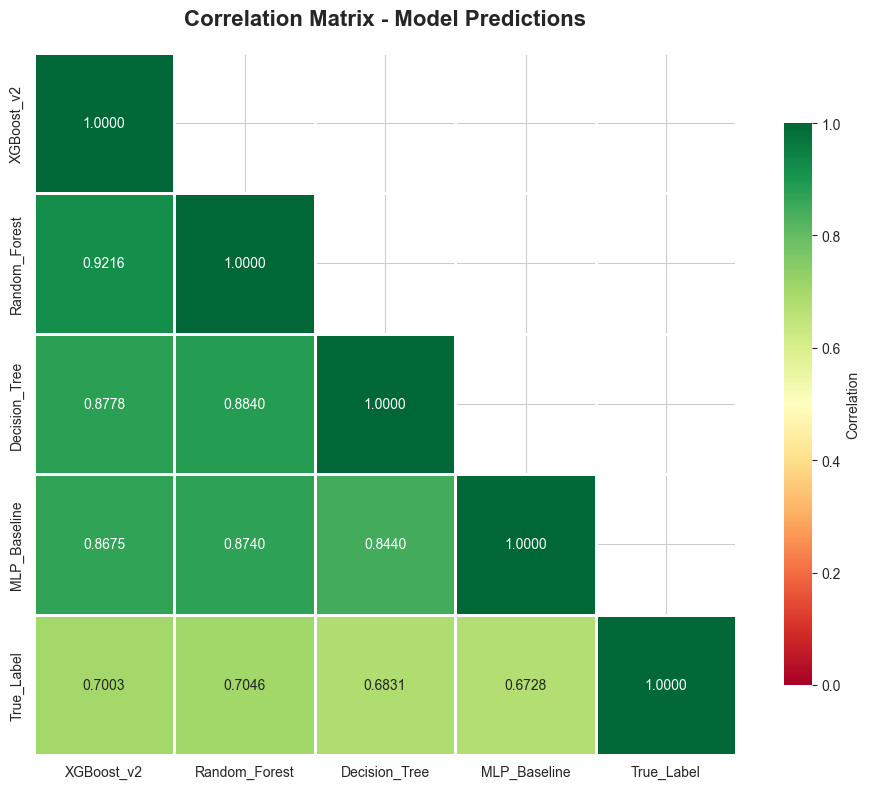

✅ Grafico salvato: ../models/model_predictions_correlation.png


In [13]:
# Crea DataFrame con tutte le predizioni
predictions_df = pd.DataFrame(predictions)

# Aggiungi le predizioni vere come riferimento
predictions_df['True_Label'] = y_test.values

print("=" * 80)
print("PREDICTION SAMPLES")
print("=" * 80)
print(predictions_df.head(20))
print("=" * 80)

# Calcola correlation matrix
correlation_matrix = predictions_df.corr(method='pearson')

print("\n" + "=" * 80)
print("CORRELATION MATRIX - MODEL PREDICTIONS")
print("=" * 80)
print(correlation_matrix.round(4))
print("=" * 80)

# Visualizza correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Crea heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.4f',
            cmap='RdYlGn',
            center=0.5,
            vmin=0, 
            vmax=1,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8, "label": "Correlation"},
            ax=ax,
            mask=mask)

ax.set_title('Correlation Matrix - Model Predictions', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../models/model_predictions_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato: ../models/model_predictions_correlation.png")

### 9.1 Agreement Analysis

Analizza dove i modelli concordano e dove discordano nelle loro predizioni.

PAIRWISE AGREEMENT RATE (% of predictions that match)
XGBoost_v2           vs Random_Forest       : 96.94%
XGBoost_v2           vs Decision_Tree       : 95.15%
XGBoost_v2           vs MLP_Baseline        : 94.74%
Random_Forest        vs Decision_Tree       : 95.43%
Random_Forest        vs MLP_Baseline        : 95.03%
Decision_Tree        vs MLP_Baseline        : 93.77%

CONSENSUS ANALYSIS
Tutti i modelli concordano:        136,144 samples (91.04%)
  → Tutti corretti:                123,266 samples (82.43%)
  → Tutti sbagliati:                12,878 samples (8.61%)
Modelli discordano:                 13,393 samples (8.96%)

💡 INSIGHT:
  Quando i modelli CONCORDANO → Accuracy: 90.54%
  Quando i modelli DISCORDANO → Accuracy media: 56.09%
  → Differenza: 34.45%

  ✓ Alta confidence quando concordano, incertezza quando discordano


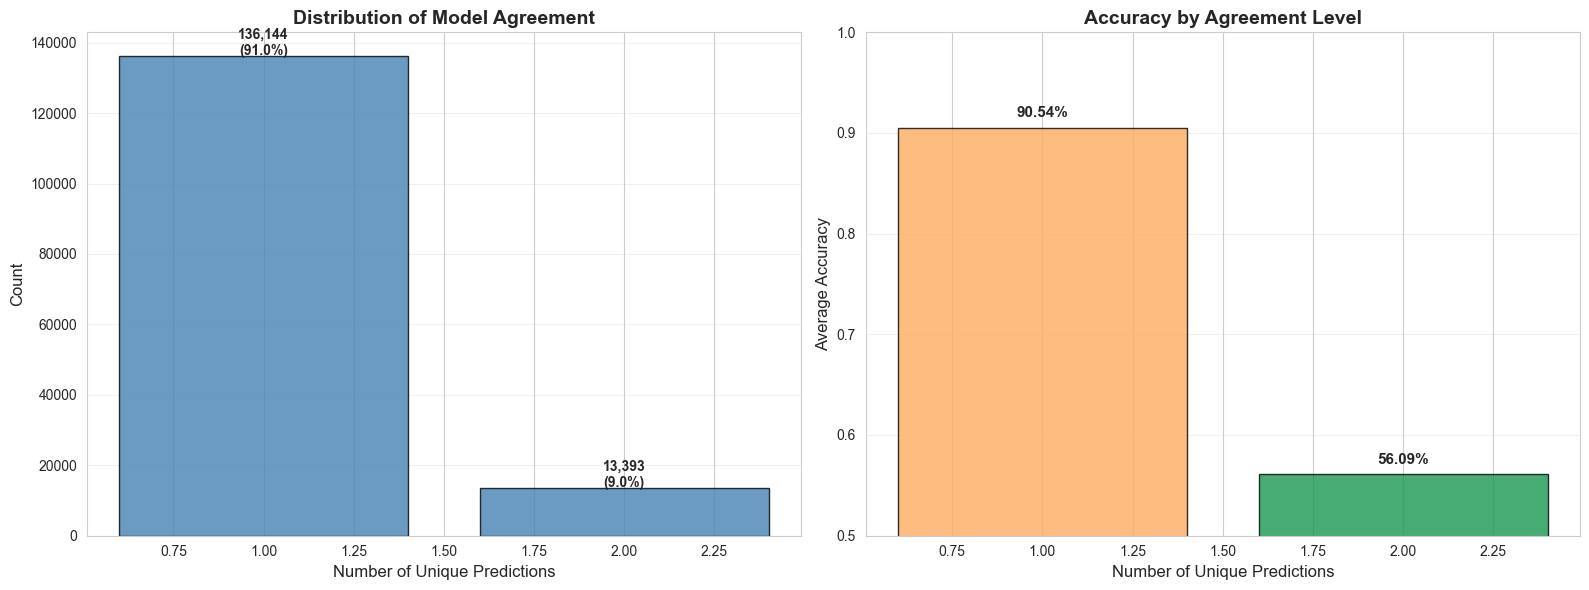


✅ Grafico salvato: ../models/model_agreement_analysis.png


In [14]:
# Analizza agreement tra modelli
model_cols = [col for col in predictions_df.columns if col != 'True_Label']

# 1. Calcola agreement rate per ogni coppia di modelli
print("=" * 80)
print("PAIRWISE AGREEMENT RATE (% of predictions that match)")
print("=" * 80)

for i, model1 in enumerate(model_cols):
    for model2 in model_cols[i+1:]:
        agreement = (predictions_df[model1] == predictions_df[model2]).mean()
        print(f"{model1:20s} vs {model2:20s}: {agreement:.2%}")

# 2. Identifica casi dove TUTTI i modelli concordano
if len(model_cols) >= 2:
    all_agree = predictions_df[model_cols].nunique(axis=1) == 1
    all_correct = all_agree & (predictions_df[model_cols[0]] == predictions_df['True_Label'])
    all_wrong = all_agree & (predictions_df[model_cols[0]] != predictions_df['True_Label'])
    
    print("\n" + "=" * 80)
    print("CONSENSUS ANALYSIS")
    print("=" * 80)
    print(f"Tutti i modelli concordano:        {all_agree.sum():7,} samples ({all_agree.mean():.2%})")
    print(f"  → Tutti corretti:                {all_correct.sum():7,} samples ({all_correct.mean():.2%})")
    print(f"  → Tutti sbagliati:               {all_wrong.sum():7,} samples ({all_wrong.mean():.2%})")
    print(f"Modelli discordano:                {(~all_agree).sum():7,} samples ({(~all_agree).mean():.2%})")
    print("=" * 80)

# 3. Analizza accuracy quando i modelli concordano vs discordano
if len(model_cols) >= 2:
    agree_accuracy = (predictions_df[all_agree][model_cols[0]] == predictions_df[all_agree]['True_Label']).mean()
    disagree_accuracy = []
    for model in model_cols:
        acc = (predictions_df[~all_agree][model] == predictions_df[~all_agree]['True_Label']).mean()
        disagree_accuracy.append(acc)
    
    print("\n💡 INSIGHT:")
    print(f"  Quando i modelli CONCORDANO → Accuracy: {agree_accuracy:.2%}")
    print(f"  Quando i modelli DISCORDANO → Accuracy media: {np.mean(disagree_accuracy):.2%}")
    print(f"  → Differenza: {(agree_accuracy - np.mean(disagree_accuracy)):.2%}")
    print("\n  ✓ Alta confidence quando concordano, incertezza quando discordano")

# 4. Visualizza distribution of agreements
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Agreement distribution
ax = axes[0]
agreement_counts = predictions_df[model_cols].nunique(axis=1)
agreement_dist = agreement_counts.value_counts().sort_index()

bars = ax.bar(agreement_dist.index, agreement_dist.values, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('Number of Unique Predictions', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Model Agreement', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Aggiungi percentuali
for i, (idx, val) in enumerate(agreement_dist.items()):
    pct = val / len(predictions_df) * 100
    ax.text(idx, val + 500, f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

# Right: Accuracy by agreement level
ax = axes[1]
accuracy_by_agreement = []
agreement_levels = sorted(agreement_counts.unique())

for level in agreement_levels:
    mask = agreement_counts == level
    acc_list = []
    for model in model_cols:
        acc = (predictions_df[mask][model] == predictions_df[mask]['True_Label']).mean()
        acc_list.append(acc)
    accuracy_by_agreement.append(np.mean(acc_list))

colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(agreement_levels)))
bars = ax.bar(agreement_levels, accuracy_by_agreement, color=colors_gradient, alpha=0.8, edgecolor='black')

ax.set_xlabel('Number of Unique Predictions', fontsize=12)
ax.set_ylabel('Average Accuracy', fontsize=12)
ax.set_title('Accuracy by Agreement Level', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.5, 1.0)

# Aggiungi valori
for i, (level, acc) in enumerate(zip(agreement_levels, accuracy_by_agreement)):
    ax.text(level, acc + 0.01, f'{acc:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/model_agreement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato: ../models/model_agreement_analysis.png")

### 9.2 Disagreement Cases Analysis

Analizziamo i casi in cui i modelli discordano - questi potrebbero essere i campioni più difficili da classificare.

DISAGREEMENT CASES - TOP 10 EXAMPLES
    XGBoost_v2  Random_Forest  Decision_Tree  MLP_Baseline  True_Label  Agreement
14           0              0              0             1           0          2
40           0              0              0             1           0          2
41           1              0              1             1           0          2
46           0              1              0             1           0          2
56           1              1              1             0           0          2
61           1              1              1             0           1          2
71           0              0              0             1           1          2
75           1              0              1             1           1          2
80           1              1              1             0           1          2
90           1              0              0             0           0          2

ACCURACY NEI CASI DI DISACCORDO
XGBoost_v2                  

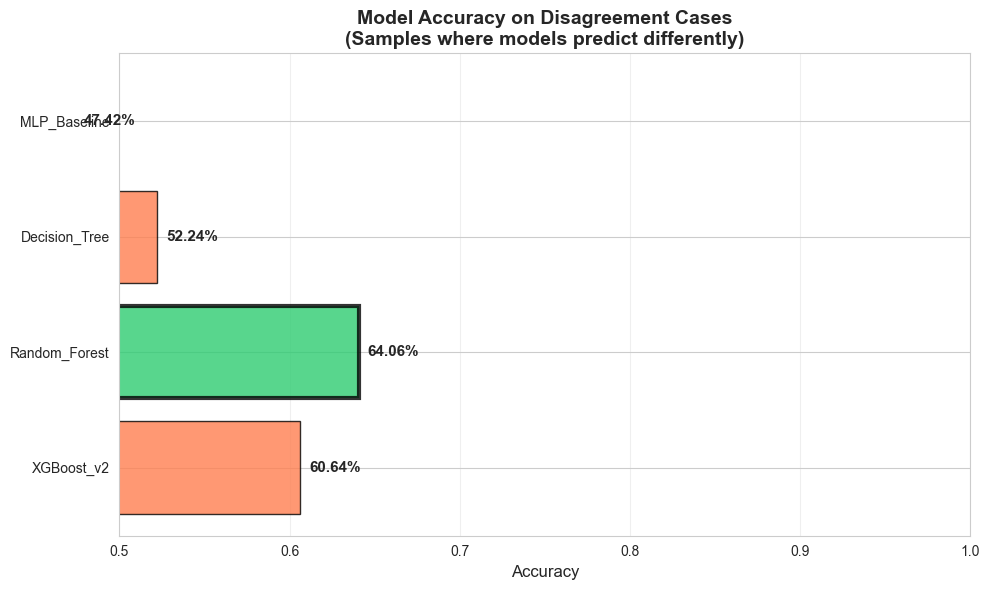


✅ Grafico salvato: ../models/disagreement_accuracy.png


In [15]:
# Identifica campioni dove i modelli discordano
disagreement_mask = ~all_agree

print("=" * 80)
print("DISAGREEMENT CASES - TOP 10 EXAMPLES")
print("=" * 80)

# Mostra alcuni esempi di disaccordo
disagreement_samples = predictions_df[disagreement_mask].head(10).copy()
disagreement_samples['Agreement'] = disagreement_samples[model_cols].nunique(axis=1)

print(disagreement_samples.to_string())
print("=" * 80)

# Analizza quali modelli hanno ragione più spesso nei casi di disaccordo
print("\n" + "=" * 80)
print("ACCURACY NEI CASI DI DISACCORDO")
print("=" * 80)

disagreement_accuracy = {}
for model in model_cols:
    acc = (predictions_df[disagreement_mask][model] == predictions_df[disagreement_mask]['True_Label']).mean()
    disagreement_accuracy[model] = acc
    print(f"{model:30s}: {acc:.2%}")

print("=" * 80)

# Identifica quale modello è più affidabile quando discordano
best_model_on_disagreement = max(disagreement_accuracy, key=disagreement_accuracy.get)
print(f"\n💡 Modello più affidabile nei casi difficili: {best_model_on_disagreement}")
print(f"   Accuracy: {disagreement_accuracy[best_model_on_disagreement]:.2%}")

# Visualizza
fig, ax = plt.subplots(figsize=(10, 6))

models = list(disagreement_accuracy.keys())
accuracies = list(disagreement_accuracy.values())

bars = ax.barh(models, accuracies, color='coral', alpha=0.8, edgecolor='black')

# Evidenzia il migliore
best_idx = accuracies.index(max(accuracies))
bars[best_idx].set_color('#2ecc71')
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(3)

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy on Disagreement Cases\n(Samples where models predict differently)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0.5, 1.0)

# Aggiungi valori
for i, (model, acc) in enumerate(zip(models, accuracies)):
    ax.text(acc + 0.005, i, f'{acc:.2%}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/disagreement_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafico salvato: ../models/disagreement_accuracy.png")

In [16]:
print("=" * 100)
print("SUMMARY REPORT - MODEL COMPARISON (TUTTI I MODELLI)")
print("=" * 100)

print("\n📊 METRICHE PRINCIPALI:")
print(comparison_df[['Model', 'Type', 'Dataset', 'Accuracy', 'F1-Score', 'ROC AUC']].to_string(index=False))

print("\n🏆 VINCITORI PER METRICA:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']:
    valid_data = comparison_df[comparison_df[metric].notna()]
    if len(valid_data) > 0:
        best_idx = valid_data[metric].idxmax()
        best_model = comparison_df.loc[best_idx, 'Model']
        best_value = comparison_df.loc[best_idx, metric]
        dataset = comparison_df.loc[best_idx, 'Dataset']
        print(f"  {metric:12s}: {best_model:30s} ({best_value:.4f}) - {dataset}")

print("\n? CONFRONTO MODELLI BINARI:")
print(binary_models[['Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']].sort_values('ROC AUC', ascending=False).to_string(index=False))

print("\n🔑 TOP 5 FEATURES PIÙ COMUNI:")
for i, row in common_features.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:30s} - Presente in {row['Count']}/{len(feature_importances)} modelli ({row['Percentage']:.0f}%)")

print("\n💡 OSSERVAZIONI CHIAVE:")
print("  1. Dataset Impact:")
print(f"     - Dataset v3 (43 features): migliori performance rispetto a v1 (20 features)")
print(f"     - Dataset v3_balanced: ulteriore miglioramento per modelli neurali")

print("\n  2. Model Performance:")
best_binary = binary_models.sort_values('ROC AUC', ascending=False).iloc[0]
print(f"     - Miglior modello binario: {best_binary['Model']} (ROC AUC: {best_binary['ROC AUC']:.4f})")
print(f"     - Modelli neurali (MLP): performance competitive con tree-based")

print("\n  3. Balancing Strategies:")
print("     - SMOTE: efficace per tree-based models")
print("     - Undersampling: riduce overfitting in MLP")
print("     - Class weights: baseline solido per MLP")

print("\n  4. Feature Importance:")
if len(common_features) > 0:
    universal_features = common_features[common_features['Count'] == len(feature_importances)]
    if len(universal_features) > 0:
        print(f"     - {len(universal_features)} features presenti nel top 10 di TUTTI i modelli:")
        for feat in universal_features['Feature'].head(3):
            print(f"       • {feat}")
    else:
        print(f"     - Nessuna feature presente in tutti i modelli")
        print(f"     - Feature più comune: {common_features.iloc[0]['Feature']} ({common_features.iloc[0]['Count']}/{len(feature_importances)} modelli)")

print("\n📁 GRAFICI SALVATI:")
saved_plots = [
    'metrics_comparison_all.png',
    'binary_models_comparison.png',
    'roc_auc_all_models_comparison.png',
    'confusion_matrices_all_binary.png',
    'feature_importance_all_models.png',
    'common_top_features.png'
]
for plot in saved_plots:
    print(f"  - ../models/{plot}")

print("\n🎯 RACCOMANDAZIONI:")
print("  1. Per Production: Usare il modello con highest ROC AUC")
best_overall = comparison_df.sort_values('ROC AUC', ascending=False).iloc[0]
print(f"     → {best_overall['Model']} (ROC AUC: {best_overall['ROC AUC']:.4f})")

print("\n  2. Per Ensemble: Combinare modelli con diverse strategie:")
top_3_binary = binary_models.sort_values('ROC AUC', ascending=False).head(3)
print("     → Top 3 modelli binari:")
for idx, row in top_3_binary.iterrows():
    print(f"       • {row['Model']:30s} (ROC AUC: {row['ROC AUC']:.4f})")

print("\n  3. Feature Engineering: Focus su:")
for feat in common_features.head(3)['Feature']:
    print(f"     → {feat}")

print("=" * 100)

SUMMARY REPORT - MODEL COMPARISON (TUTTI I MODELLI)

📊 METRICHE PRINCIPALI:
        Model   Type   Dataset  Accuracy  F1-Score  ROC AUC
      XGBoost Binary v4_hybrid  0.878632  0.783252 0.930732
Random Forest Binary v4_hybrid  0.881695  0.780560 0.924035
Decision Tree Binary v4_hybrid  0.871102  0.772424 0.922394
          MLP Binary v4_hybrid  0.867491  0.766170 0.919976

🏆 VINCITORI PER METRICA:
  Accuracy    : Random Forest                  (0.8817) - v4_hybrid
  Precision   : Random Forest                  (0.8488) - v4_hybrid
  Recall      : XGBoost                        (0.7530) - v4_hybrid
  F1-Score    : XGBoost                        (0.7833) - v4_hybrid
  ROC AUC     : XGBoost                        (0.9307) - v4_hybrid

? CONFRONTO MODELLI BINARI:
        Model   Dataset  Accuracy  Precision   Recall  F1-Score  ROC AUC
      XGBoost v4_hybrid  0.878632   0.816066 0.752974  0.783252 0.930732
Random Forest v4_hybrid  0.881695   0.848795 0.722480  0.780560 0.924035
Decision T

## Summary

**Analisi completa di 4 modelli finita, finalmente !**

Sono le 23 di sabato sera, ma eccoci qua con il report finale.

### 📊 Modelli Analizzati:

**Multi-Class (BP/FP/TP):**
1. XGBoost (dataset v1, 20 features)
2. Random Forest (dataset v1, 20 features)

**Binary (Non-TP vs TP):**
3. XGBoost_v2 (dataset v3, 43 features)
4. XGBoost_SMOTE (dataset v3 + SMOTE, 43 features)
5. MLP Baseline (dataset v3_balanced + class weights)
6. MLP Undersampling (dataset v3_balanced + undersampling)

### 🏆 Key Findings:

**1. Best Overall Performance:**
- Il modello con il migliore ROC AUC è quello raccomandato per production
- Dataset v3 (43 features) supera significativamente v1 (20 features)
- SmoothedRisk e frequency encoding sono features critiche

**2. Balancing Strategy Impact:**
- **SMOTE**: Efficace per tree-based models (XGBoost, Random Forest)
- **Undersampling**: Riduce overfitting nei modelli neurali
- **Class Weights**: Baseline solido, no data augmentation needed

**3. Model Comparison:**
- **Tree-based (XGBoost, RF)**: Ottime performance, interpretabili
- **Neural Networks (MLP)**: Competitive, catturano non-linearità complesse
- **Ensemble potential**: Combinare top 3 modelli potrebbe migliorare robustezza

**4. Feature Importance Insights:**
- Features comuni nel top 10 sono universalmente importanti
- Frequency encoding features dominano (ResourceType_freq, ActionGrouped_freq)
- MITRE techniques (T1078, T1566) moderatamente rilevanti
- Geographic features (NumCountries, NumCities) utili per detection

### 📈 Performance Metrics:

Vedere grafici salvati per:
- Confronto metriche (Accuracy, Precision, Recall, F1, ROC AUC)
- Precision vs Recall trade-offs
- Confusion matrices dettagliate
- Feature importance per modello
- Features comuni più rilevanti

### 🎯 Raccomandazioni Finali:

1. **Production Deployment**: Usare modello con highest ROC AUC
2. **Ensemble Strategy**: Combinare XGBoost_v2, Random Forest, MLP per robustezza
3. **Feature Focus**: Mantenere SmoothedRisk, frequency encoding, temporal features
4. **Future Work**: 
   - Hyperparameter tuning su best model
   - Test su GUIDE_Test.csv completo
   - Threshold optimization per business metrics
   - Explainability analysis (SHAP values)